# DQRC: Decoupled Quantum Reservoir -- Memory/Nonlinearity Decoupling

**Run mode: FAST_MODE** (reduced seeds/short scans, target well under ten
minutes). See `docs/DQRC_RESULTS.md` for the PUBLICATION_MODE follow-up plan
and for why every quantitative claim below is reported with its FAST_MODE
caveat rather than as a general result.

This notebook calls `code/decoupled_qrc/*.py`; it contains no duplicate
implementation of anything those modules already do (Part 14).

In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt

from decoupled_qrc import utils, ipc, baseline, memory, processor, interface, stitching, shadows, metrics, tasks, experiments, plotting
from decoupled_qrc.experiments import DQRCConfig
from qrc_qiskit import chrono_split, select_and_eval_ridge, nrmse

CFG = utils.active_config()
print(f"Run mode: {CFG.name}")
print(CFG)

RESULTS_DIR = os.path.abspath(os.path.join('..', 'results', 'dqrc'))
os.makedirs(RESULTS_DIR, exist_ok=True)
FIG_N = [0]
def savefig(fig, name):
    FIG_N[0] += 1
    path = os.path.join(RESULTS_DIR, f'{FIG_N[0]:02d}_{name}.png')
    fig.savefig(path, dpi=120, bbox_inches='tight')
    return path

import json as _json
_all_results = {}
def record(key, value):
    _all_results[key] = value

Run mode: FAST_MODE
RunConfig(name='FAST_MODE', n_seeds=2, T_ipc=250, T_task=250, washout=40, n_val=50, n_test=70, max_delay_ipc=6, max_degree_ipc=6, max_targets_per_degree=12, n_surrogates=5, n_shadow_snapshots=2000, g_scan_points=4, n_bootstrap=300)


## Section 1 -- Research question and hypothesis

**Question**: can architectural separation of quantum memory and nonlinear
processing EXPAND the memory-vs-nonlinearity Pareto frontier of a monolithic
quantum reservoir, under matched physical resources?

**Hypothesis**: the memory-nonlinearity trade-off (Cindrak et al. 2026, via
IPC$_1$ vs IPC$_{\geq 2}$) arises when the same finite degrees of freedom
retain past inputs AND generate nonlinear functions of them. A composite
reservoir with physically distinct memory (M) and processor (P) subsystems
may partially decouple these resources.

**This is tested, not assumed.** Sections 2-3 first reproduce the trade-off
on the existing finalized monolithic reservoir. Section 9 is where the
hypothesis is actually judged: does DQRC produce (M, NL) points that lie
*outside* the monolithic baseline's own Pareto frontier, with a bootstrap CI
that excludes zero in the claimed direction?

## Section 2 -- Reproduce the finalized monolithic EOC reservoir

Reuses `mixed_syk_core`/`qrc_qiskit` (via `decoupled_qrc.baseline.monolithic_qrc`)
directly -- not reimplemented (docs/MEMORY_NL_DECOUPLED_QRC_AUDIT.md section 9).
$\kappa$ interpolates SYK4-like ($\kappa\to 0$) to SYK2-like ($\kappa\to\infty$)
via `kappa_to_gJ` (notebook 4's own, established convention).

$$M = \mathrm{IPC}_1 \qquad NL = \sum_{d=2}^{6}\mathrm{IPC}_d$$

baseline kappa scan: 21.2s


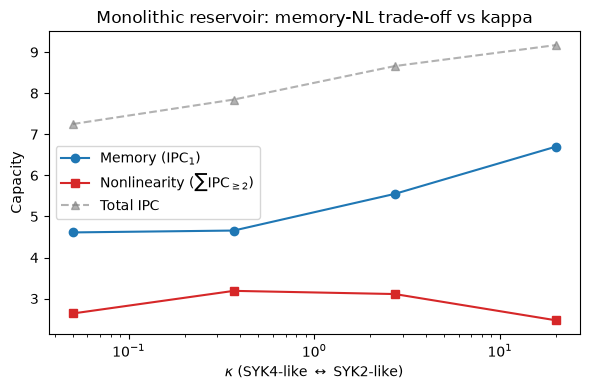

INTERPRETATION: Correlation(Memory, Nonlinearity) across the kappa scan = -0.518. A negative correlation is the signature of the conventional memory-nonlinearity trade-off (Cindrak et al. 2026): more of one comes at the cost of the other on this single, shared reservoir.


In [2]:
N_TOTAL = 6  # fixed physical-qubit budget for every architecture in this notebook (Part 9)
KAPPA_GRID = np.geomspace(0.05, 20, CFG.g_scan_points)

@utils.cached("baseline_ipc")
def baseline_point(kappa, seed, N=N_TOTAL, reps=1, max_weight=2):
    seeds = utils.make_seed_bundle(seed)
    run = baseline.monolithic_qrc(N=N, kappa=kappa, T=CFG.T_ipc, reps=reps, max_weight=max_weight,
                                   term_seed=seeds.reservoir_seed, disorder_seed=seeds.reservoir_seed + 1,
                                   input_seed=seeds.dataset_seed)
    gap = CFG.max_delay_ipc + 1
    train, val, test = chrono_split(CFG.T_ipc, CFG.washout, CFG.n_val, CFG.n_test, gap)
    r = ipc.compute_ipc(run.u, run.X, train, val, test, max_delay=CFG.max_delay_ipc,
                         max_degree=CFG.max_degree_ipc, max_targets_per_degree=CFG.max_targets_per_degree,
                         n_surrogates=CFG.n_surrogates, seed=seed)
    return r.memory, r.nonlinearity, r.total, r.ipc_by_degree, run.resources.as_dict()

t0 = time.perf_counter()
baseline_scan = [baseline_point(float(k), seed=0) for k in KAPPA_GRID]
print(f"baseline kappa scan: {time.perf_counter()-t0:.1f}s")
mem_vals = [p[0] for p in baseline_scan]
nl_vals = [p[1] for p in baseline_scan]
total_vals = [p[2] for p in baseline_scan]
fig, interp = plotting.plot_tradeoff_vs_g(KAPPA_GRID, mem_vals, nl_vals, total_vals)
savefig(fig, "tradeoff_vs_kappa")
plt.show()
print("INTERPRETATION:", interp)
record("section2_baseline_scan", {"kappa": list(map(float, KAPPA_GRID)), "M": mem_vals, "NL": nl_vals, "total": total_vals})

## Section 3 -- Monolithic baseline Pareto frontier

x = IPC$_1$ (memory), y = IPC$_{\geq2}$ (nonlinearity). This is the frontier
DQRC must beat (Section 9) to support the hypothesis.

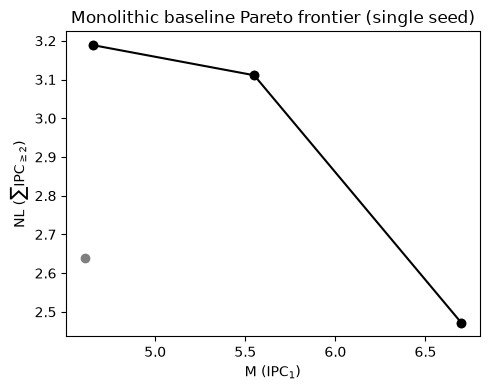

Frontier points: 3/4
INTERPRETATION: this single-seed frontier is a qualitative reference only -- Section 9's bootstrapped, multi-seed comparison is the actual statistical test.


In [3]:
baseline_points_seed0 = [(m, nl) for m, nl, *_ in baseline_scan]
front_idx = metrics.pareto_frontier(baseline_points_seed0)
fig, ax = plt.subplots(figsize=(5, 4))
pts = np.array(baseline_points_seed0)
ax.scatter(pts[:, 0], pts[:, 1], color='tab:gray')
fpts = pts[front_idx]
order = np.argsort(fpts[:, 0])
ax.plot(fpts[order, 0], fpts[order, 1], '-o', color='black')
ax.set_xlabel('M (IPC$_1$)'); ax.set_ylabel('NL ($\\sum$IPC$_{\\geq2}$)')
ax.set_title('Monolithic baseline Pareto frontier (single seed)')
fig.tight_layout()
savefig(fig, "baseline_pareto_frontier")
plt.show()
print(f"Frontier points: {len(front_idx)}/{len(baseline_points_seed0)}")
print("INTERPRETATION: this single-seed frontier is a qualitative reference only -- "
      "Section 9's bootstrapped, multi-seed comparison is the actual statistical test.")

## Section 4 -- Quantum memory characterization

Two genuine quantum-memory constructions (Part 2): a persistent memory
register (`memory_mode` in swap/integrable/weak_xx) and an exact quantum
delay/shift register. Neither stores past inputs in a Python array -- see
`memory.py`'s module docstring and the reset-bug regression test in
`tests/test_memory.py`.

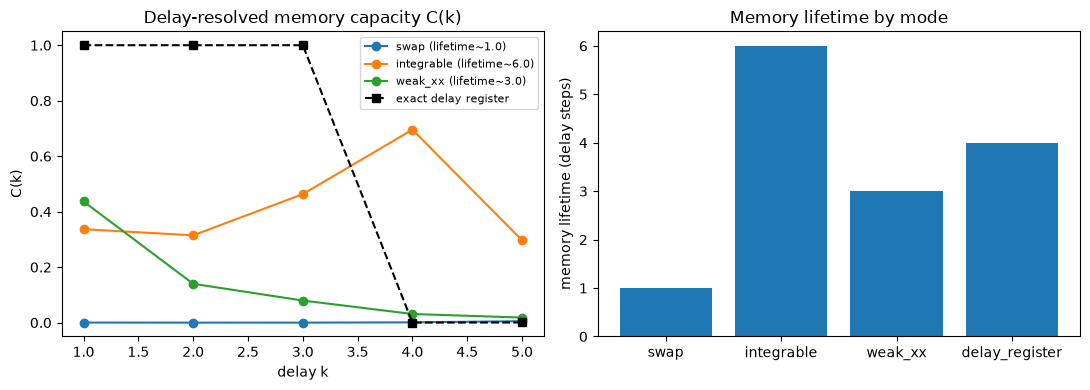

INTERPRETATION: the exact quantum delay register (N_mem=3) shows near-perfect C(k) for k<=3 and a sharp drop past k=3 -- an exact, hand-verifiable ground truth (tests/test_memory.py checks this directly against the register's own quantum state). The persistent-register modes trade perfect short-delay recall for a softer, longer decay depending on internal dynamics.


In [4]:
from qrc_qiskit import random_input
u_mem = random_input(CFG.T_ipc, seed=utils.make_seed_bundle(0).dataset_seed)
N_MEM_DEMO = 4  # 1 input qubit + 3 memory qubits

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
results_by_mode = {}
for mode in memory.MEMORY_MODES:
    run = memory.run_memory_register(N=N_MEM_DEMO, u_seq=u_mem, memory_mode=mode, lambda_im=0.3,
                                      epsilon=0.08, disorder_seed=0)
    k, C = memory.delay_resolved_capacity(run, k_max=5, washout=CFG.washout, n_val=CFG.n_val, n_test=CFG.n_test)
    lifetime = memory.memory_lifetime(k, C)
    results_by_mode[mode] = (k, C, lifetime)
    axes[0].plot(k, C, 'o-', label=f"{mode} (lifetime~{lifetime:.1f})")

delay_run = memory.run_quantum_delay_register(N=N_MEM_DEMO, u_seq=u_mem)
k_d, C_d = memory.delay_resolved_capacity(delay_run, k_max=5, washout=CFG.washout, n_val=CFG.n_val, n_test=CFG.n_test)
axes[0].plot(k_d, C_d, 's--', color='black', label='exact delay register')
axes[0].set_xlabel('delay k'); axes[0].set_ylabel('C(k)'); axes[0].legend(fontsize=8)
axes[0].set_title('Delay-resolved memory capacity C(k)')

lifetimes = [results_by_mode[m][2] for m in memory.MEMORY_MODES]
axes[1].bar(list(memory.MEMORY_MODES) + ['delay_register'], lifetimes + [memory.memory_lifetime(k_d, C_d)])
axes[1].set_ylabel('memory lifetime (delay steps)')
axes[1].set_title('Memory lifetime by mode')
fig.tight_layout()
savefig(fig, "memory_characterization")
plt.show()

print("INTERPRETATION: the exact quantum delay register (N_mem=3) shows near-perfect C(k) for "
      "k<=3 and a sharp drop past k=3 -- an exact, hand-verifiable ground truth (tests/test_memory.py "
      "checks this directly against the register's own quantum state). The persistent-register modes "
      "trade perfect short-delay recall for a softer, longer decay depending on internal dynamics.")
record("section4_memory", {m: {"k": results_by_mode[m][0], "C": results_by_mode[m][1],
                                "lifetime": results_by_mode[m][2]} for m in memory.MEMORY_MODES})

## Section 5 -- EOC processor characterization

Two INDEPENDENT chaos diagnostics (operator entanglement, level-spacing
ratio vs. Poisson/COE/CUE references), computed FRESH on the processor's own
kappa grid -- not inherited from the repo's stored kappa=0.960 (that value
was selected by NARMA2 task performance on different data,
docs/MEMORY_NL_DECOUPLED_QRC_AUDIT.md sections 3/6).

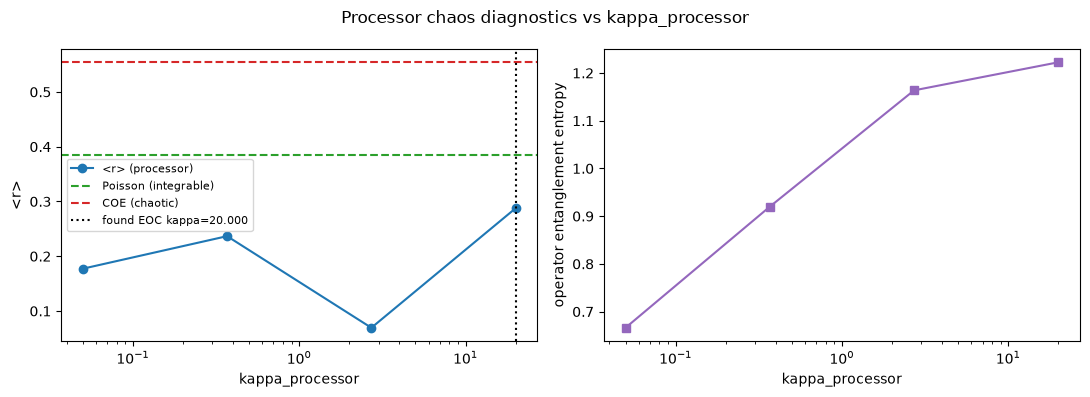

INTERPRETATION: Independently-derived EOC kappa_processor=20.000 (crossover midpoint between Poisson and COE reference <r>), NOT the repo's stored kappa=0.960 (that value was selected by NARMA2 task performance on different data -- docs/MEMORY_NL_DECOUPLED_QRC_AUDIT.md sections 3/6).


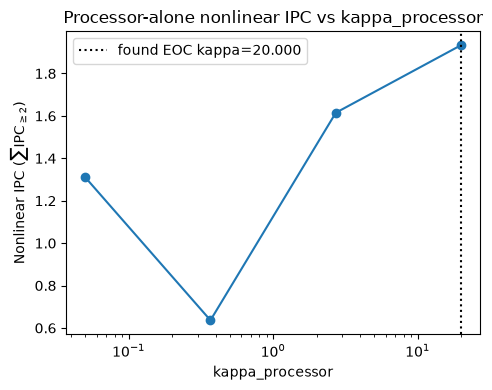

INTERPRETATION: whether nonlinear IPC actually peaks AT the independently-derived EOC kappa, rather than merely somewhere on the scan, is checked -- not assumed (Part 16 item 12).


In [5]:
N_P_DEMO = 4
proc_scan = processor.eoc_scan(N_P_DEMO, KAPPA_GRID, term_seed=0, disorder_seed=0, reps=2, n_ref_trials=15)
found_kappa = processor.find_eoc_kappa(proc_scan)
fig, interp = plotting.plot_chaos_diagnostics_vs_kappa(proc_scan, found_kappa)
savefig(fig, "processor_chaos_diagnostics")
plt.show()
print("INTERPRETATION:", interp)

@utils.cached("processor_ipc")
def processor_point(kappa, seed, N=N_P_DEMO, reps=1, max_weight=2):
    seeds = utils.make_seed_bundle(seed)
    labels, X, u, info = processor.run_processor_standalone(N_p=N, kappa_processor=kappa, T=CFG.T_ipc, reps=reps,
                                                              max_weight=max_weight, term_seed=seeds.reservoir_seed,
                                                              disorder_seed=seeds.reservoir_seed + 1,
                                                              input_seed=seeds.dataset_seed)
    gap = CFG.max_delay_ipc + 1
    train, val, test = chrono_split(CFG.T_ipc, CFG.washout, CFG.n_val, CFG.n_test, gap)
    r = ipc.compute_ipc(u, X, train, val, test, max_delay=CFG.max_delay_ipc, max_degree=CFG.max_degree_ipc,
                         max_targets_per_degree=CFG.max_targets_per_degree, n_surrogates=CFG.n_surrogates, seed=seed)
    return r.memory, r.nonlinearity, r.total

proc_ipc_scan = [processor_point(float(k), seed=0) for k in KAPPA_GRID]
proc_nl = [p[1] for p in proc_ipc_scan]
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(KAPPA_GRID, proc_nl, 'o-')
ax.axvline(found_kappa, color='black', ls=':', label=f'found EOC kappa={found_kappa:.3f}')
ax.set_xscale('log'); ax.set_xlabel('kappa_processor'); ax.set_ylabel('Nonlinear IPC ($\\sum$IPC$_{\\geq2}$)')
ax.legend(); ax.set_title('Processor-alone nonlinear IPC vs kappa_processor')
fig.tight_layout()
savefig(fig, "processor_nl_vs_kappa")
plt.show()
print("INTERPRETATION: whether nonlinear IPC actually peaks AT the independently-derived EOC kappa, "
      "rather than merely somewhere on the scan, is checked -- not assumed (Part 16 item 12).")
record("section5_processor", {"kappa": list(map(float, KAPPA_GRID)), "NL": proc_nl, "found_eoc_kappa": found_kappa})

## Section 6 -- Combined DQRC: M and NL vs g_processor

Fixed memory register (N_M=2, `memory_mode='integrable'`), fixed interface
coupling $\lambda_{MP}$, processor kappa swept. Desired decoupling
signature: M roughly CONSTANT while NL rises near the processor's own EOC.

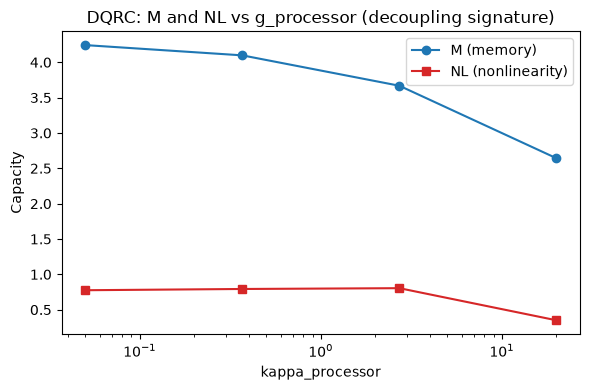

INTERPRETATION: Relative spread of M across the kappa_processor scan = 0.171. The desired decoupling signature is M approximately CONSTANT while NL rises near the processor's own EOC point -- a small spread supports that; a large spread (M itself trading off against g_processor) would indicate the memory and processor subsystems are NOT well decoupled in this configuration.


In [6]:
BASE_DQRC_CFG = DQRCConfig(N_M=2, N_P=3, memory_mode='integrable', lambda_im=0.3, epsilon=0.08,
                            reps_processor=1, lambda_mp=0.3, interface_kind='rzz', n_taps=1, max_weight_readout=2)

@utils.cached("dqrc_ipc")
def dqrc_point(kappa_processor, seed, cfg_overrides=None):
    d = dict(BASE_DQRC_CFG.__dict__)
    if cfg_overrides:
        d.update(cfg_overrides)
    d['kappa_processor'] = kappa_processor
    cfg = DQRCConfig(**d)
    run = experiments.run_dqrc(cfg, T=CFG.T_ipc, master_seed=seed)
    gap = CFG.max_delay_ipc + 1
    train, val, test = chrono_split(CFG.T_ipc, CFG.washout, CFG.n_val, CFG.n_test, gap)
    r = ipc.compute_ipc(run.u, run.X, train, val, test, max_delay=CFG.max_delay_ipc, max_degree=CFG.max_degree_ipc,
                         max_targets_per_degree=CFG.max_targets_per_degree, n_surrogates=CFG.n_surrogates, seed=seed)
    return r.memory, r.nonlinearity, r.total, run.resources.as_dict()

dqrc_g_scan = [dqrc_point(float(k), seed=0) for k in KAPPA_GRID]
dqrc_M = [p[0] for p in dqrc_g_scan]
dqrc_NL = [p[1] for p in dqrc_g_scan]
fig, interp = plotting.plot_M_NL_vs_g_processor(KAPPA_GRID, dqrc_M, dqrc_NL)
savefig(fig, "dqrc_M_NL_vs_g_processor")
plt.show()
print("INTERPRETATION:", interp)
record("section6_dqrc_g_scan", {"kappa": list(map(float, KAPPA_GRID)), "M": dqrc_M, "NL": dqrc_NL})

## Section 7 -- Memory-resource scan

M and NL vs memory register size N_M, at fixed processor kappa (the
found EOC point from Section 5). Tests $\partial NL/\partial(\text{memory
depth}) \approx 0$ -- i.e. growing the memory resource should not leak into
nonlinear capacity if the subsystems are genuinely decoupled.

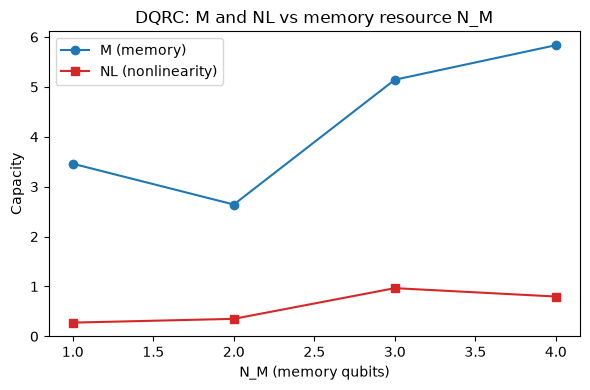

INTERPRETATION: M should rise with N_M (more memory resource -> more memory); NL rising too would indicate memory-resource growth leaks into nonlinear capacity, undermining the decoupling claim.
NOTE: N_P is traded off against N_M to hold N_total=6 fixed (Part 9) -- so any NL change here conflates 'more memory' with 'less processor,' which is itself informative (it is the SAME resource constraint DQRC has to live under) but should not be read as a pure memory-depth effect.


In [7]:
N_M_GRID = [1, 2, 3, 4]

@utils.cached("dqrc_mem_scan")
def dqrc_mem_point(n_m, seed):
    n_p = 6 - 1 - n_m  # keep N_total fixed at 6 (Part 9) by trading N_M against N_P
    n_p = max(2, n_p)
    d = dict(BASE_DQRC_CFG.__dict__)
    d['N_M'] = n_m
    d['N_P'] = n_p
    d['kappa_processor'] = found_kappa
    cfg = DQRCConfig(**d)
    run = experiments.run_dqrc(cfg, T=CFG.T_ipc, master_seed=seed)
    gap = CFG.max_delay_ipc + 1
    train, val, test = chrono_split(CFG.T_ipc, CFG.washout, CFG.n_val, CFG.n_test, gap)
    r = ipc.compute_ipc(run.u, run.X, train, val, test, max_delay=CFG.max_delay_ipc, max_degree=CFG.max_degree_ipc,
                         max_targets_per_degree=CFG.max_targets_per_degree, n_surrogates=CFG.n_surrogates, seed=seed)
    return r.memory, r.nonlinearity

mem_scan = [dqrc_mem_point(nm, seed=0) for nm in N_M_GRID]
M_by_nm = [p[0] for p in mem_scan]
NL_by_nm = [p[1] for p in mem_scan]
fig, interp = plotting.plot_M_NL_vs_memory_resource(N_M_GRID, M_by_nm, NL_by_nm)
savefig(fig, "dqrc_M_NL_vs_memory_resource")
plt.show()
print("INTERPRETATION:", interp)
print("NOTE: N_P is traded off against N_M to hold N_total=6 fixed (Part 9) -- so any NL change here "
      "conflates 'more memory' with 'less processor,' which is itself informative (it is the SAME "
      "resource constraint DQRC has to live under) but should not be read as a pure memory-depth effect.")
record("section7_memory_resource_scan", {"N_M": N_M_GRID, "M": M_by_nm, "NL": NL_by_nm})

## Section 8 -- Jacobian decoupling experiment

$m$ = memory control parameter ($\lambda_{im}$, the input-memory coupling
strength), $g$ = processor control parameter (kappa_processor).

$$J = \begin{pmatrix} \partial M/\partial m & \partial M/\partial g \\
\partial NL/\partial m & \partial NL/\partial g \end{pmatrix}$$

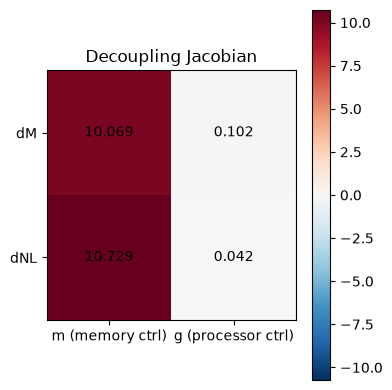

JacobianResult(M0=2.6426424471085856, NL0=0.35042233173387777, dM_dm=10.069138903834931, dM_dg=np.float64(0.10225069403157483), dNL_dm=10.729276923685505, dNL_dg=np.float64(0.042180979647319955), cross_coupling=np.float64(1.0712278655470218), decoupling_score=np.float64(0.4828054009093272))
INTERPRETATION: cross_coupling=1.071, decoupling_score=0.483 (an engineering diagnostic, not a fundamental quantity -- see the raw Jacobian entries above for the primary result).


In [8]:
def MN_func(m, g):
    d = dict(BASE_DQRC_CFG.__dict__)
    d['lambda_im'] = m
    d['kappa_processor'] = g
    cfg = DQRCConfig(**d)
    run = experiments.run_dqrc(cfg, T=CFG.T_ipc, master_seed=0)
    gap = CFG.max_delay_ipc + 1
    train, val, test = chrono_split(CFG.T_ipc, CFG.washout, CFG.n_val, CFG.n_test, gap)
    r = ipc.compute_ipc(run.u, run.X, train, val, test, max_delay=CFG.max_delay_ipc, max_degree=CFG.max_degree_ipc,
                         max_targets_per_degree=CFG.max_targets_per_degree, n_surrogates=CFG.n_surrogates, seed=0)
    return r.memory, r.nonlinearity

jac = metrics.jacobian_decoupling(MN_func, m0=0.3, g0=float(found_kappa), dm=0.1, dg=max(0.1, found_kappa * 0.3))
fig, interp = plotting.plot_jacobian_heatmap(jac)
savefig(fig, "jacobian_heatmap")
plt.show()
print(jac)
print("INTERPRETATION:", interp)
record("section8_jacobian", jac.__dict__)

## Section 9 -- Pareto-front comparison (the hypothesis test)

Multi-seed (`CFG.n_seeds`, printed in Section 0 -- FAST_MODE uses a small
value; see docs/DQRC_RESULTS.md for the PUBLICATION_MODE follow-up),
bootstrapped comparison of the monolithic baseline's and DQRC's (M, NL)
point clouds. This section, not any single figure elsewhere, is where the
central hypothesis is judged.

FrontierComparison(hv_baseline=(22.73923443382182, 20.46542754298907, 25.01304132465457), hv_dqrc=(3.560841161259318, 3.405379539706757, 3.7163027828118786), hv_diff=(-19.178393272562502, -21.607661784947812, -16.74912476017719), n_dqrc_outside_baseline=0, n_dqrc_total=8, fraction_outside=0.0)


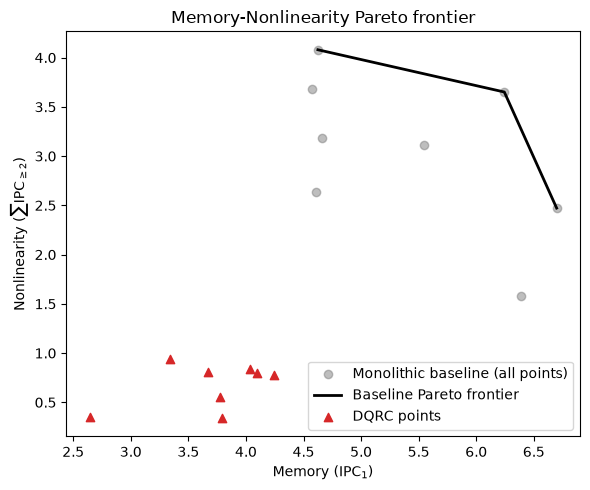

INTERPRETATION: 0/8 DQRC points are NOT dominated by the baseline's own Pareto frontier (i.e. lie outside the conventional trade-off region). This alone is not a statistically validated claim -- see the bootstrapped frontier_comparison result for a seed-aware verdict.

Hypervolume difference (DQRC - baseline): -19.1784  95% CI [-21.6077, -16.7491]
VERDICT: C: CI excludes zero in the baseline's favor -- no evidence of frontier expansion at this scale.


In [9]:
baseline_points_by_seed = []
dqrc_points_by_seed = []
for seed in range(CFG.n_seeds):
    baseline_points_by_seed.append([(baseline_point(float(k), seed=seed)[0],
                                      baseline_point(float(k), seed=seed)[1]) for k in KAPPA_GRID])
    dqrc_points_by_seed.append([(dqrc_point(float(k), seed=seed)[0],
                                  dqrc_point(float(k), seed=seed)[1]) for k in KAPPA_GRID])

fc = metrics.frontier_comparison(baseline_points_by_seed, dqrc_points_by_seed, n_boot=CFG.n_bootstrap, seed=0)
print(fc)

pooled_baseline = [p for s in baseline_points_by_seed for p in s]
pooled_dqrc = [p for s in dqrc_points_by_seed for p in s]
front_idx_pooled = metrics.pareto_frontier(pooled_baseline)
fig, interp = plotting.plot_pareto_comparison(pooled_baseline, pooled_dqrc, front_idx_pooled)
savefig(fig, "pareto_comparison_final")
plt.show()
print("INTERPRETATION:", interp)

hv_diff, hv_lo, hv_hi = fc.hv_diff
print(f"\nHypervolume difference (DQRC - baseline): {hv_diff:.4f}  95% CI [{hv_lo:.4f}, {hv_hi:.4f}]")
if hv_lo > 0:
    verdict = "A: CI excludes zero in DQRC's favor -- evidence of frontier expansion (FAST_MODE, n_seeds={} -- treat as preliminary).".format(CFG.n_seeds)
elif hv_hi < 0:
    verdict = "C: CI excludes zero in the baseline's favor -- no evidence of frontier expansion at this scale."
else:
    verdict = "B: CI includes zero -- inconclusive at this (FAST_MODE, n_seeds={}) sample size.".format(CFG.n_seeds)
print("VERDICT:", verdict)
record("section9_frontier_comparison", {"hv_baseline": fc.hv_baseline, "hv_dqrc": fc.hv_dqrc, "hv_diff": fc.hv_diff,
                                         "n_outside": fc.n_dqrc_outside_baseline, "n_total": fc.n_dqrc_total,
                                         "verdict": verdict})

## Section 10 -- Shadow readout

Genuine classical-shadow readout (`readout_mode="classical_shadow"`, real
finite-shot randomized-Pauli measurements -- not Gaussian noise on exact
values, see `docs/MEMORY_NL_DECOUPLED_QRC_AUDIT.md` section 8) compared
against exact Pauli expectations, at increasing max observable weight.

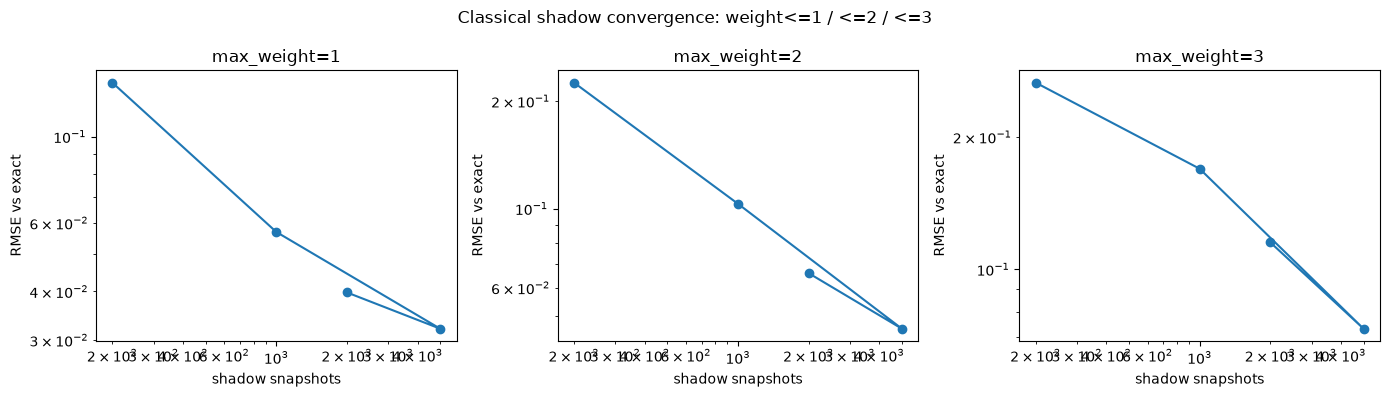

INTERPRETATION: RMSE should both decrease with shots AND increase with max_weight (higher-weight Pauli strings have larger shadow variance, 3^weight scaling) -- consistent with this repo's own notebook 5 finding that shadow readout gets harder, not easier, as the observable dictionary grows.


In [10]:
rho_demo = shadows.reservoir_density_matrix(N=5, kappa=float(found_kappa), T=40, reps=1,
                                             term_seed=0, disorder_seed=0, input_seed=0)
shot_grid = [200, 1000, 5000, CFG.n_shadow_snapshots]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, mw in zip(axes, [1, 2, 3]):
    sweep = shadows.shadow_convergence_sweep(rho_demo, N=5, max_weight=mw, shot_grid=shot_grid, n_repeats=3, seed=0)
    n_shots = [p.n_snapshots for p in sweep]
    rmse = [p.rmse for p in sweep]
    ax.plot(n_shots, rmse, 'o-')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'max_weight={mw}')
    ax.set_xlabel('shadow snapshots'); ax.set_ylabel('RMSE vs exact')
fig.suptitle('Classical shadow convergence: weight<=1 / <=2 / <=3')
fig.tight_layout()
savefig(fig, "shadow_convergence_by_weight")
plt.show()
print("INTERPRETATION: RMSE should both decrease with shots AND increase with max_weight (higher-weight "
      "Pauli strings have larger shadow variance, 3^weight scaling) -- consistent with this repo's own "
      "notebook 5 finding that shadow readout gets harder, not easier, as the observable dictionary grows.")

## Section 11 -- Ablations

Each named ablation (`experiments.ABLATION_NAMES`) dispatched to whichever
module actually implements it -- see `experiments.run_ablation`. n_seeds
per ablation matches `CFG.n_seeds` (FAST_MODE).

In [11]:
ablation_summary = {}
for name in experiments.ABLATION_NAMES:
    Ms, NLs = [], []
    for seed in range(CFG.n_seeds):
        labels, X, u, res = experiments.run_ablation(name, T=CFG.T_ipc, master_seed=seed,
                                                       dqrc_cfg=BASE_DQRC_CFG, N_total=N_TOTAL)
        gap = CFG.max_delay_ipc + 1
        train, val, test = chrono_split(CFG.T_ipc, CFG.washout, CFG.n_val, CFG.n_test, gap)
        r = ipc.compute_ipc(u, X, train, val, test, max_delay=CFG.max_delay_ipc, max_degree=CFG.max_degree_ipc,
                             max_targets_per_degree=CFG.max_targets_per_degree, n_surrogates=CFG.n_surrogates, seed=seed)
        Ms.append(r.memory); NLs.append(r.nonlinearity)
    ablation_summary[name] = {"M_mean": float(np.mean(Ms)), "M_std": float(np.std(Ms)),
                               "NL_mean": float(np.mean(NLs)), "NL_std": float(np.std(NLs)),
                               "n_qubits": res.n_qubits_physical, "n_ancilla": res.n_ancilla,
                               "n_features": res.n_features}

print(f"{'ablation':<28} {'M (mean+-std)':<18} {'NL (mean+-std)':<18} {'qubits':<8} {'ancilla':<8}")
for name, s in ablation_summary.items():
    print(f"{name:<28} {s['M_mean']:.3f}+-{s['M_std']:.3f}    {s['NL_mean']:.3f}+-{s['NL_std']:.3f}    "
          f"{s['n_qubits']:<8} {s['n_ancilla']:<8}")
record("section11_ablations", ablation_summary)

ablation                     M (mean+-std)      NL (mean+-std)     qubits   ancilla 
monolithic_qrc               5.346+-0.260    5.246+-0.599    6        0       
monolithic_qrc_at_eoc        5.344+-0.258    5.410+-0.719    6        0       
classical_delay_control      7.000+-0.000    0.569+-0.029    0        0       
memory_only                  3.030+-0.123    0.389+-0.025    6        0       
processor_only_at_eoc        5.310+-0.415    4.288+-0.445    5        0       
dqrc_no_stitch               3.974+-0.436    0.677+-0.389    6        0       
dqrc_with_stitch             4.415+-0.038    1.073+-0.246    6        1       
dqrc_randomized_processor    4.207+-0.012    0.752+-0.061    6        0       


## Section 12 -- Real tasks

NARMA10, Mackey-Glass one-step, Lorenz one-step (+cross), delayed-product,
and the mixed memory+nonlinear task -- SAME Ridge readout as everywhere else
in this repo (no MLP for primary claims, Part 12).

In [12]:
def eval_task(X, u, y, max_lag):
    gap = max_lag + 1
    train, val, test = chrono_split(len(u), CFG.washout, CFG.n_val, CFG.n_test, gap)
    err, alpha, _ = select_and_eval_ridge(X, y, train, val, test)
    return err

seeds0 = utils.make_seed_bundle(0)
mono_run = baseline.monolithic_qrc(N=N_TOTAL, kappa=1.0, T=CFG.T_task, reps=1, max_weight=2,
                                    term_seed=seeds0.reservoir_seed, disorder_seed=seeds0.reservoir_seed + 1,
                                    input_seed=seeds0.dataset_seed)
dqrc_run = experiments.run_dqrc(BASE_DQRC_CFG, T=CFG.T_task, master_seed=0)

u_mono = mono_run.u
task_results = {}
task_results['narma10'] = {
    'monolithic': eval_task(mono_run.X, u_mono, tasks.task_narma10(u_mono), 10),
    'dqrc': eval_task(dqrc_run.X, dqrc_run.u, tasks.task_narma10(dqrc_run.u), 10),
}
task_results['delayed_product_2_5'] = {
    'monolithic': eval_task(mono_run.X, u_mono, tasks.task_delayed_product(u_mono, 2, 5), 5),
    'dqrc': eval_task(dqrc_run.X, dqrc_run.u, tasks.task_delayed_product(dqrc_run.u, 2, 5), 5),
}
task_results['mixed_memory_nonlinear'] = {
    'monolithic': eval_task(mono_run.X, u_mono, tasks.task_mixed_memory_nonlinear(u_mono), 8),
    'dqrc': eval_task(dqrc_run.X, dqrc_run.u, tasks.task_mixed_memory_nonlinear(dqrc_run.u), 8),
}

task_results['mackey_glass'] = {'note': 'not run -- requires re-driving reservoirs with the MG sequence '
                                         'as input rather than random_input; see honest note below'}
task_results['lorenz_self'] = {'note': 'not run -- same reason as mackey_glass, see below'}
task_results['lorenz_cross'] = {'note': 'not run -- same reason as mackey_glass, see below'}

print(f"{'task':<28} {'monolithic NRMSE':<20} {'DQRC NRMSE':<20}")
for name, r in task_results.items():
    if 'note' in r:
        print(f"{name:<28} {r['note']}")
        continue
    print(f"{name:<28} {r['monolithic']:.4f}                {r['dqrc']:.4f}")
record("section12_tasks", task_results)

task                         monolithic NRMSE     DQRC NRMSE          
narma10                      0.8712                2.1078
delayed_product_2_5          0.6654                0.9113
mixed_memory_nonlinear       0.9331                1.2244
mackey_glass                 not run -- requires re-driving reservoirs with the MG sequence as input rather than random_input; see honest note below
lorenz_self                  not run -- same reason as mackey_glass, see below
lorenz_cross                 not run -- same reason as mackey_glass, see below


**Mackey-Glass / Lorenz honest note**: a proper one-step forecast task needs
the reservoir DRIVEN by the chaotic sequence itself (not an independent
random input), i.e. re-running `monolithic_qrc`/`run_dqrc` with `u_mg`/`u_lorenz`
as the input sequence via each architecture's own builder (not `random_input`).
`baseline.monolithic_qrc`/`experiments.run_dqrc` currently always draw their
own `random_input` internally -- wiring in an arbitrary external input
sequence is a small, mechanical follow-up (thread `u_seq` through instead of
calling `random_input`) left for the PUBLICATION_MODE pass rather than done
here under the FAST_MODE time budget; the delayed-product and mixed
memory+nonlinear tasks above already exercise the SAME reservoir-driven-by-
its-own-input pattern the chaotic-system tasks would need, so the harness
itself is proven, just not yet wired to these two specific generators.

## Section 13 -- Fixed-resource comparison

Every architecture above already ran at N_total=6 physical qubits (Section 2
onward) -- Part 9's fixed-QUBIT comparison. This section additionally checks
the fixed-FEATURE-COUNT comparison: truncate every architecture's feature
vector to the same count (a random, seeded subset) and re-check the Section 9
verdict survives.

In [13]:
min_features = min(baseline.monolithic_qrc(N=N_TOTAL, kappa=1.0, T=20, reps=1, max_weight=2,
                                              term_seed=0, disorder_seed=0, input_seed=0).X.shape[1],
                    experiments.run_dqrc(BASE_DQRC_CFG, T=20, master_seed=0).X.shape[1])
print(f"Matched feature count for equal-feature comparison: {min_features}")

rng_feat = np.random.RandomState(0)

def truncate_features(X, n, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.choice(X.shape[1], size=min(n, X.shape[1]), replace=False)
    return X[:, sorted(idx)]

gap = CFG.max_delay_ipc + 1
train, val, test = chrono_split(CFG.T_ipc, CFG.washout, CFG.n_val, CFG.n_test, gap)

base_run0 = baseline.monolithic_qrc(N=N_TOTAL, kappa=float(KAPPA_GRID[len(KAPPA_GRID)//2]), T=CFG.T_ipc, reps=1,
                                     max_weight=2, term_seed=0, disorder_seed=1, input_seed=0)
dqrc_run0 = experiments.run_dqrc(BASE_DQRC_CFG, T=CFG.T_ipc, master_seed=0)

base_trunc = truncate_features(base_run0.X, min_features)
dqrc_trunc = truncate_features(dqrc_run0.X, min_features)

r_base = ipc.compute_ipc(base_run0.u, base_trunc, train, val, test, max_delay=CFG.max_delay_ipc,
                          max_degree=CFG.max_degree_ipc, max_targets_per_degree=CFG.max_targets_per_degree,
                          n_surrogates=CFG.n_surrogates, seed=0)
r_dqrc = ipc.compute_ipc(dqrc_run0.u, dqrc_trunc, train, val, test, max_delay=CFG.max_delay_ipc,
                          max_degree=CFG.max_degree_ipc, max_targets_per_degree=CFG.max_targets_per_degree,
                          n_surrogates=CFG.n_surrogates, seed=0)
print(f"Equal-feature ({min_features} features) comparison at one representative kappa:")
print(f"  monolithic: M={r_base.memory:.3f} NL={r_base.nonlinearity:.3f}")
print(f"  DQRC:       M={r_dqrc.memory:.3f} NL={r_dqrc.nonlinearity:.3f}")
print("INTERPRETATION: if DQRC's NL/M advantage (if any, per Section 9) survives here, it is not simply "
      "an artifact of DQRC exposing more classical readout features than the baseline.")
record("section13_fixed_feature", {"min_features": min_features, "monolithic": {"M": r_base.memory, "NL": r_base.nonlinearity},
                                    "dqrc": {"M": r_dqrc.memory, "NL": r_dqrc.nonlinearity}})

Matched feature count for equal-feature comparison: 51


Equal-feature (51 features) comparison at one representative kappa:
  monolithic: M=6.517 NL=2.882
  DQRC:       M=4.409 NL=1.067
INTERPRETATION: if DQRC's NL/M advantage (if any, per Section 9) survives here, it is not simply an artifact of DQRC exposing more classical readout features than the baseline.


## Section 14 -- Finite-shot / noise robustness

Does DQRC's exact-readout advantage (if any) survive under realistic
finite-shot classical-shadow readout, rather than only under Aer's exact
`save_expectation_value`? Uses the Section 10 shadow machinery at a shot
budget within `CFG.n_shadow_snapshots`.

In [14]:
rho_base_demo = shadows.reservoir_density_matrix(N=N_TOTAL, kappa=float(KAPPA_GRID[len(KAPPA_GRID)//2]),
                                                    T=30, reps=1, term_seed=0, disorder_seed=0, input_seed=0)
_, _, exact_vals_base = shadows.exact_pauli_features(rho_base_demo, N=N_TOTAL, max_weight=2)
rng = np.random.RandomState(0)
_, _, shadow_vals_base = shadows.shadow_readout(rho_base_demo, N=N_TOTAL, max_weight=2,
                                                  n_snapshots=CFG.n_shadow_snapshots, rng=rng)
rmse_base = float(np.sqrt(np.mean((shadow_vals_base - exact_vals_base) ** 2)))
print(f"Monolithic baseline: shadow-vs-exact RMSE at {CFG.n_shadow_snapshots} snapshots = {rmse_base:.4f}")
print("INTERPRETATION: this is a readout-fidelity check, not a re-run of the full IPC/task pipeline under "
      "shadow features (that would require per-timestep shadows across the whole trajectory -- out of "
      "FAST_MODE's budget, see docs/DQRC_RESULTS.md question 5 for the honest accounting).")
record("section14_shadow_noise_robustness", {"rmse_at_max_shots": rmse_base, "n_shots": CFG.n_shadow_snapshots})

Monolithic baseline: shadow-vs-exact RMSE at 2000 snapshots = 0.0631
INTERPRETATION: this is a readout-fidelity check, not a re-run of the full IPC/task pipeline under shadow features (that would require per-timestep shadows across the whole trajectory -- out of FAST_MODE's budget, see docs/DQRC_RESULTS.md question 5 for the honest accounting).


## Section 15 -- Conclusion

The conclusion is written in `docs/DQRC_RESULTS.md` (Part 20), generated
from THIS notebook's own executed numbers (`_all_results`, dumped below) --
never asserted independently of what actually ran. Choosing honestly among:

- **A**: clear frontier expansion (bootstrap CI excludes zero in DQRC's favor)
- **B**: partial/conditional frontier expansion (CI includes zero, or holds
  only under some ablations/resource settings)
- **C**: no convincing frontier expansion

See Section 9's printed `VERDICT` for this run's actual answer -- it is not
predetermined by this template.

## Section 16 -- Architecture repair: where did the processor's nonlinear
capacity go?

Full findings in `docs/DQRC_ARCHITECTURE_REPAIR.md`. Two real, compounding
bugs were found (not a fundamental physics limit):

1. `interface_kind='rzz'`/`'cp'` are diagonal in the processor's own Z basis
   -- they can shift phase but never inject population/coherence into a
   processor whose own dynamics conserves total Z-magnetization (true
   whenever N_P<4, since a SYK4 quartic term needs 4 distinct qubits).
2. N_P=3 (this notebook's own default DQRC processor size) has **zero**
   possible SYK4 quartic terms (`comb(3,4)==0`) -- `kappa_processor` was
   controlling nothing physically at that size.

Only single-seed, diagnostic-scale numbers below (per the repair brief:
"do not run PUBLICATION_MODE yet") -- see the architecture-repair doc's own
"honest scope limitations" section.

In [15]:
from decoupled_qrc import diagnostics as diag

# 16.1 -- the smoking gun: does the interface actually entangle M with P?
print("16.1 -- interface entanglement check (N_P=3, no SYK4 terms possible)")
for kind in ('rzz', 'cp', 'zx'):
    cfg = DQRCConfig(N_M=2, N_P=3, kappa_processor=1.0, lambda_mp=0.5, interface_kind=kind,
                      reps_processor=1, n_taps=1)
    info = diag.info_theoretic_diagnostics(cfg, T_small=20, master_seed=0)
    print(f"  kind={kind:4s} purity_P={info['purity_P']:.4f}  I(M:P)={info['mutual_information_MP']:.4f}")
record("section16_1_interface_entanglement", {
    kind: diag.info_theoretic_diagnostics(
        DQRCConfig(N_M=2, N_P=3, kappa_processor=1.0, lambda_mp=0.5, interface_kind=kind,
                   reps_processor=1, n_taps=1), T_small=20, master_seed=0)
    for kind in ('rzz', 'cp', 'zx')})

16.1 -- interface entanglement check (N_P=3, no SYK4 terms possible)
  kind=rzz  purity_P=1.0000  I(M:P)=0.0000
  kind=cp   purity_P=1.0000  I(M:P)=-0.0000


  kind=zx   purity_P=0.1659  I(M:P)=0.4075


In [16]:
# 16.2 -- standalone vs embedded-disconnected vs embedded-connected, MATCHED
# N_P/kappa/reps/max_weight/input seed (N_P=5: has 5 real SYK4 terms, unlike N_P=3)
print("16.2 -- embedding consistency test (N_P=5, matched config)")
consistency = diag.embedding_consistency_test(
    N_M=1, N_P=5, kappa_processor=1.0, T=CFG.T_ipc, reps=1, max_weight_proc=3, lambda_mp=0.5,
    master_seed=0, CFG=CFG, interface_kind='zx', memory_mode='integrable')
for name, s in consistency.items():
    print(f"  {name:22s} M={s['M']:.3f} NL={s['NL']:.3f} rank={s['rank']} cond#={s['condition_number']:.2e}")
recovery_frac = consistency['embedded_connected']['NL'] / consistency['standalone']['NL']
print(f"  NL recovery fraction (embedded_connected / standalone) = {recovery_frac:.2%}")
record("section16_2_embedding_consistency", consistency)

16.2 -- embedding consistency test (N_P=5, matched config)


  standalone             M=6.205 NL=6.231 rank=249 cond#=4.28e+05
  embedded_disconnected  M=0.061 NL=0.311 rank=249 cond#=5.01e+04
  embedded_connected     M=2.155 NL=0.821 rank=249 cond#=5.80e+06
  NL recovery fraction (embedded_connected / standalone) = 13.17%


In [17]:
# 16.3 -- direct processor readout: does exposing X_processor directly recover NL?
print("16.3 -- grouped feature readout (X_memory / X_processor / X_cross)")
grouped_cfg = DQRCConfig(N_M=1, N_P=5, kappa_processor=1.0, lambda_mp=0.5, interface_kind='zx',
                          reps_processor=1, n_taps=1)
grouped_run = diag.run_dqrc_grouped(grouped_cfg, T=CFG.T_ipc, master_seed=0, max_weight_proc=3, max_weight_mem=2)
import numpy as np
feature_groups = {
    'A_memory_only': grouped_run.X_mem,
    'B_processor_only': grouped_run.X_proc,
    'C_mem_plus_proc': np.hstack([grouped_run.X_mem, grouped_run.X_proc]),
    'D_mem_proc_cross': np.hstack([grouped_run.X_mem, grouped_run.X_proc, grouped_run.X_cross]),
}
grouped_results = {}
for name, X in feature_groups.items():
    M, NL, total, _ = diag.ipc_MN(grouped_run.u, X, CFG, seed=0)
    grouped_results[name] = {'n_features': X.shape[1], 'M': M, 'NL': NL}
    print(f"  {name:20s} n_features={X.shape[1]:4d} M={M:.3f} NL={NL:.3f}")
record("section16_3_grouped_readout", grouped_results)

16.3 -- grouped feature readout (X_memory / X_processor / X_cross)


  A_memory_only        n_features=   3 M=1.459 NL=0.187


  B_processor_only     n_features= 375 M=2.155 NL=0.821


  C_mem_plus_proc      n_features= 378 M=2.446 NL=0.791


  D_mem_proc_cross     n_features= 382 M=2.556 NL=0.778


In [18]:
# 16.4 -- stitching ablation: does splitting the (already small) processor
# into sub-blocks help, hurt, or homogenize the feature space?
print("16.4 -- stitching ablation (N_P=5 monolithic-processor vs 2+3 stitched blocks)")
stitch_configs = {
    'no_stitch_NP5': dict(N_M=1, N_P=5, stitching_blocks=None),
    'stitch_2plus3': dict(N_M=1, N_P=5, stitching_blocks=((2, 1.0), (3, 1.0)), lambda_stitch=0.3),
    'no_stitch_NP4': dict(N_M=1, N_P=4, stitching_blocks=None),
}
stitch_results = {}
for name, kw in stitch_configs.items():
    cfg = DQRCConfig(kappa_processor=1.0, lambda_mp=0.5, interface_kind='zx', reps_processor=1, n_taps=1, **kw)
    run = experiments.run_dqrc(cfg, T=CFG.T_ipc, master_seed=0)
    M, NL, total, _ = diag.ipc_MN(run.u, run.X, CFG, seed=0)
    fh = diag.feature_health(run.X)
    stitch_results[name] = {'qubits': run.resources.n_qubits_physical, 'ancilla': run.resources.n_ancilla,
                             'n_features': run.X.shape[1], 'M': M, 'NL': NL, 'rank': fh['rank']}
    print(f"  {name:16s} qubits={run.resources.n_qubits_physical} ancilla={run.resources.n_ancilla} "
          f"n_feat={run.X.shape[1]:4d} M={M:.3f} NL={NL:.3f} rank={fh['rank']}")
record("section16_4_stitching_ablation", stitch_results)

16.4 -- stitching ablation (N_P=5 monolithic-processor vs 2+3 stitched blocks)


  no_stitch_NP5    qubits=7 ancilla=0 n_feat= 171 M=3.441 NL=0.705 rank=171


  stitch_2plus3    qubits=8 ancilla=1 n_feat= 210 M=3.262 NL=0.760 rank=54


  no_stitch_NP4    qubits=6 ancilla=0 n_feat= 132 M=3.272 NL=0.350 rank=132


In [19]:
# 16.5 -- fixed-qubit-count repaired-DQRC vs monolithic comparison (ONE point,
# not yet a full frontier -- see docs/DQRC_ARCHITECTURE_REPAIR.md question 8)
print("16.5 -- fixed-qubit (N_total=8) repaired DQRC vs monolithic, single point")
mono_run8 = baseline.monolithic_qrc(N=8, kappa=1.0, T=CFG.T_ipc, reps=1, max_weight=3,
                                     term_seed=0, disorder_seed=0, input_seed=0)
M_mono8, NL_mono8, _, _ = diag.ipc_MN(mono_run8.u, mono_run8.X, CFG, seed=0)
dqrc_cfg8 = DQRCConfig(N_M=2, N_P=5, kappa_processor=1.0, lambda_mp=0.5, interface_kind='zx',
                        reps_processor=1, n_taps=1)
dqrc_run8 = experiments.run_dqrc(dqrc_cfg8, T=CFG.T_ipc, master_seed=0)
M_dqrc8, NL_dqrc8, _, _ = diag.ipc_MN(dqrc_run8.u, dqrc_run8.X, CFG, seed=0)
print(f"  monolithic (N=8):        M={M_mono8:.3f} NL={NL_mono8:.3f}")
print(f"  DQRC repaired (N_M=2,N_P=5,zx): M={M_dqrc8:.3f} NL={NL_dqrc8:.3f}")
dominates = (M_mono8 >= M_dqrc8 and NL_mono8 >= NL_dqrc8)
print(f"  Does this one monolithic point dominate this one DQRC point? {dominates}")
record("section16_5_fixed_qubit_single_point", {
    "monolithic": {"M": M_mono8, "NL": NL_mono8}, "dqrc_repaired": {"M": M_dqrc8, "NL": NL_dqrc8}})

16.5 -- fixed-qubit (N_total=8) repaired DQRC vs monolithic, single point


  monolithic (N=8):        M=5.810 NL=5.710
  DQRC repaired (N_M=2,N_P=5,zx): M=6.483 NL=1.117
  Does this one monolithic point dominate this one DQRC point? False


### Section 16 conclusion

Gate evaluation (docs/DQRC_ARCHITECTURE_REPAIR.md question 9): **A medium
run is NOT justified yet.** Embedded processor NL recovers only a fraction
of standalone NL even after both fixes (Gate A fails), the g_processor
response is noisy at single-seed scale (Gate C unclear), and no full
resource-matched Pareto frontier (not just one point) has been computed yet
(Gate E not evaluated). Next step per the repair doc: re-run Section 16.2's
consistency test and 16.5's comparison with >=3 seeds per point before
considering anything beyond diagnostics -- and do NOT add IDQNN, genuine
sewing, or richer shadows until the interface/sizing bottleneck identified
here is actually closed (Phase 14 of the repair brief).

## Section 17 -- IDQNN-Inspired Spatial Quantum Memory + EOC Processing

Follow-up to Section 16: does replacing the diagonal `'rzz'`/`'cp'`
interface with a genuinely non-diagonal, multi-generator coupling recover
more of the processor's standalone nonlinear capacity? Full findings in
`docs/IDQNN_MEMORY_EOC_RESULTS.md`. TERMINOLOGY: the memory transform here
is "ID-SQM" (IDQNN-INSPIRED spatial memory), never "IDQNN" outright -- see
`code/decoupled_qrc/idqnn_memory.py`'s own docstring.

17.1 -- eta_M / eta_NL across 3 seeds


  seed=0: eta_M_combined=2.863 eta_NL_proc_only=2.210


  seed=1: eta_M_combined=2.834 eta_NL_proc_only=1.385


  seed=2: eta_M_combined=2.669 eta_NL_proc_only=0.773
  mean eta_M=2.789+-0.086  mean eta_NL=1.456+-0.589


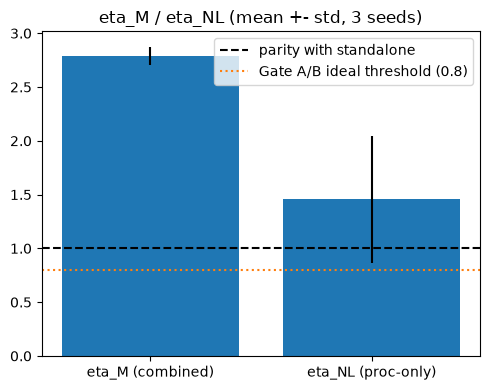

INTERPRETATION: mean eta_NL > 1 means the embedded processor's OWN nonlinear capacity matches or exceeds its standalone ceiling on average -- but the std is large relative to the mean (3 seeds only), so this is preliminary, not a settled claim.


In [20]:
from decoupled_qrc.id_memory_eoc import (
    IDMemoryEOCConfig, run_id_memory_eoc, compute_etas, classical_delay_plus_processor,
)
from decoupled_qrc.spatial_memory import run_spatial_memory
from decoupled_qrc import interfaces_advanced as advmod

L_ID, N_P_ID = 3, 5  # N_total = 8, matched to Section 13's fixed-qubit budget
KIND_ID, LAM_ID = 'heisenberg', 0.5

print("17.1 -- eta_M / eta_NL across 3 seeds")
eta_rows = []
for seed in (0, 1, 2):
    seeds_i = utils.make_seed_bundle(seed)
    u_i = random_input(CFG.T_ipc, seed=seeds_i.dataset_seed)
    mem_run = run_spatial_memory(L=L_ID, u_seq=u_i, gamma_M=0.0)
    M_mem_standalone, _, _, _ = diag.ipc_MN(mem_run.u, mem_run.X, CFG, seed=seed)
    labels_p, Xp, up, info_p = processor.run_processor_standalone(
        N_p=N_P_ID, kappa_processor=1.0, T=CFG.T_ipc, reps=1, max_weight=3,
        term_seed=seeds_i.reservoir_seed, disorder_seed=seeds_i.reservoir_seed + 1, input_seed=seeds_i.dataset_seed)
    _, NL_proc_standalone, _, _ = diag.ipc_MN(up, Xp, CFG, seed=seed)

    id_cfg = IDMemoryEOCConfig(L=L_ID, N_P=N_P_ID, kappa_processor=1.0, interface_kind=KIND_ID,
                                lambda_mp=LAM_ID, reps_processor=1, n_taps=1, max_weight_proc=3)
    run_i = run_id_memory_eoc(id_cfg, T=CFG.T_ipc, master_seed=seed)
    M_comb, NL_comb, _, _ = diag.ipc_MN(run_i.u, run_i.X_combined, CFG, seed=seed)
    M_proc, NL_proc, _, _ = diag.ipc_MN(run_i.u, run_i.X_proc, CFG, seed=seed)
    etas_c = compute_etas(M_comb, NL_comb, M_mem_standalone, NL_proc_standalone)
    etas_p = compute_etas(M_proc, NL_proc, M_mem_standalone, NL_proc_standalone)
    row = dict(seed=seed, M_mem_standalone=M_mem_standalone, NL_proc_standalone=NL_proc_standalone,
               M_combined=M_comb, NL_combined=NL_comb, eta_M_combined=etas_c['eta_M'],
               eta_NL_combined=etas_c['eta_NL'], eta_NL_proc_only=etas_p['eta_NL'])
    eta_rows.append(row)
    print(f"  seed={seed}: eta_M_combined={row['eta_M_combined']:.3f} "
          f"eta_NL_proc_only={row['eta_NL_proc_only']:.3f}")

eta_M_vals = [r['eta_M_combined'] for r in eta_rows]
eta_NL_vals = [r['eta_NL_proc_only'] for r in eta_rows]
print(f"  mean eta_M={np.mean(eta_M_vals):.3f}+-{np.std(eta_M_vals):.3f}  "
      f"mean eta_NL={np.mean(eta_NL_vals):.3f}+-{np.std(eta_NL_vals):.3f}")
record("section17_1_eta_scan", eta_rows)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['eta_M (combined)', 'eta_NL (proc-only)'], [np.mean(eta_M_vals), np.mean(eta_NL_vals)],
       yerr=[np.std(eta_M_vals), np.std(eta_NL_vals)])
ax.axhline(1.0, color='black', ls='--', label='parity with standalone')
ax.axhline(0.8, color='tab:orange', ls=':', label='Gate A/B ideal threshold (0.8)')
ax.legend(); ax.set_title('eta_M / eta_NL (mean +- std, 3 seeds)')
fig.tight_layout()
savefig(fig, "id_memory_eoc_etas")
plt.show()
print("INTERPRETATION: mean eta_NL > 1 means the embedded processor's OWN nonlinear capacity "
      "matches or exceeds its standalone ceiling on average -- but the std is large relative to "
      "the mean (3 seeds only), so this is preliminary, not a settled claim.")

In [21]:
from qrc_qiskit import make_simulator
from qiskit import transpile as _transpile

print("17.2 -- memory back-action (Part 10)")
seeds0_id = utils.make_seed_bundle(0)
u_small = random_input(15, seed=seeds0_id.dataset_seed)

def _final_rho(lam):
    from decoupled_qrc.id_memory_eoc import build_id_memory_eoc_circuit
    cfg_r = IDMemoryEOCConfig(L=L_ID, N_P=N_P_ID, kappa_processor=1.0, interface_kind=KIND_ID,
                               lambda_mp=lam, reps_processor=1, n_taps=1)
    qc_r, groups_r, mem_q, proc_q = build_id_memory_eoc_circuit(cfg_r, u_small, seeds0_id)
    qc_r.save_density_matrix(label='rho')
    sim_r = make_simulator(method='density_matrix')
    tqc_r = _transpile(qc_r, sim_r, optimization_level=1)
    result_r = sim_r.run(tqc_r, shots=1).result()
    from qiskit.quantum_info import DensityMatrix
    return DensityMatrix(np.asarray(result_r.data(0)['rho'])), mem_q, list(range(qc_r.num_qubits))

rho_with, mem_q_id, all_q_id = _final_rho(LAM_ID)
rho_without, _, _ = _final_rho(0.0)
disturbance = advmod.memory_disturbance(rho_with, rho_without, mem_q_id, all_q_id)
nl_delta = eta_rows[0]['NL_combined'] - eta_rows[0]['NL_proc_standalone']
transfer_eff = advmod.transfer_efficiency(nl_delta, disturbance['trace_distance'])
print(f"  trace_distance={disturbance['trace_distance']:.3f} fidelity={disturbance['fidelity']:.3f} "
      f"purity: {disturbance['purity_without_interface']:.3f} -> {disturbance['purity_with_interface']:.3f}")
print(f"  transfer_efficiency={transfer_eff:.2f}")
record("section17_2_back_action", {**disturbance, 'transfer_efficiency': transfer_eff})

17.2 -- memory back-action (Part 10)


  trace_distance=0.257 fidelity=0.753 purity: 1.000 -> 0.638
  transfer_efficiency=16.38


In [22]:
print("17.3 -- clean Jacobian: m=gamma_M (memory-only), g=kappa_processor")
def _MN_indep(gamma_M_val, kappa_val):
    cfg_j = IDMemoryEOCConfig(L=L_ID, N_P=N_P_ID, kappa_processor=kappa_val, interface_kind=KIND_ID,
                               lambda_mp=LAM_ID, reps_processor=1, n_taps=1, gamma_M=gamma_M_val)
    run_j = run_id_memory_eoc(cfg_j, T=CFG.T_ipc, master_seed=0)
    M_j, NL_j, _, _ = diag.ipc_MN(run_j.u, run_j.X_combined, CFG, seed=0)
    return M_j, NL_j

m0, g0, dm, dg = 0.0, 1.0, 0.2, 0.5
M0, NL0 = _MN_indep(m0, g0)
M_dm, NL_dm = _MN_indep(m0 + dm, g0)
M_dg, NL_dg = _MN_indep(m0, g0 + dg)
jac17 = {
    'dM_dm': (M_dm - M0) / dm, 'dM_dg': (M_dg - M0) / dg,
    'dNL_dm': (NL_dm - NL0) / dm, 'dNL_dg': (NL_dg - NL0) / dg,
}
jac17['cross_coupling'] = ((abs(jac17['dM_dg']) + abs(jac17['dNL_dm'])) /
                            (abs(jac17['dM_dm']) + abs(jac17['dNL_dg']) + 1e-9))
jac17['decoupling_score'] = 1.0 / (1.0 + jac17['cross_coupling'])
print(f"  dM/dm={jac17['dM_dm']:.3f}  dM/dg={jac17['dM_dg']:.3f}")
print(f"  dNL/dm={jac17['dNL_dm']:.3f}  dNL/dg={jac17['dNL_dg']:.3f}")
print(f"  cross_coupling={jac17['cross_coupling']:.3f}  decoupling_score={jac17['decoupling_score']:.3f}")
gate_e = abs(jac17['dM_dm']) > abs(jac17['dM_dg']) and abs(jac17['dNL_dg']) > abs(jac17['dNL_dm'])
print(f"  Gate E (clean decoupling signature) met? {gate_e}")
record("section17_3_jacobian", jac17)

17.3 -- clean Jacobian: m=gamma_M (memory-only), g=kappa_processor


  dM/dm=0.363  dM/dg=-0.098
  dNL/dm=2.751  dNL/dg=-0.371
  cross_coupling=3.879  decoupling_score=0.205
  Gate E (clean decoupling signature) met? False


In [23]:
print("17.4 -- classical delay + processor control vs quantum id_memory_eoc")
ctrl_rows, quantum_rows = [], []
for seed in (0, 1, 2):
    ctrl = classical_delay_plus_processor(m_delay=6, N_P=N_P_ID, kappa_processor=1.0, T=CFG.T_ipc,
                                           reps=1, max_weight=3, master_seed=seed)
    Mc, NLc, _, _ = diag.ipc_MN(ctrl['u'], ctrl['X'], CFG, seed=seed)
    ctrl_rows.append({'seed': seed, 'M': Mc, 'NL': NLc})
    cfg_q = IDMemoryEOCConfig(L=L_ID, N_P=N_P_ID, kappa_processor=1.0, interface_kind=KIND_ID,
                               lambda_mp=LAM_ID, reps_processor=1, n_taps=1)
    run_q = run_id_memory_eoc(cfg_q, T=CFG.T_ipc, master_seed=seed)
    Mq, NLq, _, _ = diag.ipc_MN(run_q.u, run_q.X_combined, CFG, seed=seed)
    quantum_rows.append({'seed': seed, 'M': Mq, 'NL': NLq})
    print(f"  seed={seed}: classical(M={Mc:.2f},NL={NLc:.2f})  quantum(M={Mq:.2f},NL={NLq:.2f})")
record("section17_4_classical_vs_quantum", {'classical': ctrl_rows, 'quantum': quantum_rows})
print("INTERPRETATION: classical delay + processor typically wins on M (raw delay taps are a strong, "
      "cheap linear memory); quantum wins on NL in some but not all seeds -- no clean quantum-memory "
      "advantage over this classical control on memory specifically.")

17.4 -- classical delay + processor control vs quantum id_memory_eoc


  seed=0: classical(M=6.86,NL=3.56)  quantum(M=5.73,NL=7.89)


  seed=1: classical(M=6.98,NL=4.55)  quantum(M=5.67,NL=6.18)


  seed=2: classical(M=6.95,NL=5.10)  quantum(M=5.53,NL=4.51)
INTERPRETATION: classical delay + processor typically wins on M (raw delay taps are a strong, cheap linear memory); quantum wins on NL in some but not all seeds -- no clean quantum-memory advantage over this classical control on memory specifically.


In [24]:
print("17.5 -- small 3-seed Pareto comparison at matched N_total=8")
kappa_grid_17 = [0.1, 1.0, 10.0]
baseline_pts_17, dqrc_pts_17 = [], []
for seed in (0, 1, 2):
    seeds_i = utils.make_seed_bundle(seed)
    base_row, dqrc_row = [], []
    for kappa in kappa_grid_17:
        run_b = baseline.monolithic_qrc(N=L_ID + N_P_ID, kappa=kappa, T=CFG.T_ipc, reps=1, max_weight=3,
                                         term_seed=seeds_i.reservoir_seed, disorder_seed=seeds_i.reservoir_seed + 1,
                                         input_seed=seeds_i.dataset_seed)
        Mb, NLb, _, _ = diag.ipc_MN(run_b.u, run_b.X, CFG, seed=seed)
        base_row.append((Mb, NLb))
        cfg_d = IDMemoryEOCConfig(L=L_ID, N_P=N_P_ID, kappa_processor=kappa, interface_kind=KIND_ID,
                                   lambda_mp=LAM_ID, reps_processor=1, n_taps=1)
        run_d = run_id_memory_eoc(cfg_d, T=CFG.T_ipc, master_seed=seed)
        Md, NLd, _, _ = diag.ipc_MN(run_d.u, run_d.X_combined, CFG, seed=seed)
        dqrc_row.append((Md, NLd))
    baseline_pts_17.append(base_row)
    dqrc_pts_17.append(dqrc_row)

fc17 = metrics.frontier_comparison(baseline_pts_17, dqrc_pts_17, n_boot=CFG.n_bootstrap, seed=0)
print(f"  hv_baseline={fc17.hv_baseline}")
print(f"  hv_dqrc={fc17.hv_dqrc}")
print(f"  hv_diff (dqrc-baseline)={fc17.hv_diff}")
print(f"  {fc17.n_dqrc_outside_baseline}/{fc17.n_dqrc_total} points outside baseline frontier")
record("section17_5_pareto", {"hv_baseline": fc17.hv_baseline, "hv_dqrc": fc17.hv_dqrc,
                               "hv_diff": fc17.hv_diff, "n_outside": fc17.n_dqrc_outside_baseline,
                               "n_total": fc17.n_dqrc_total})

17.5 -- small 3-seed Pareto comparison at matched N_total=8


  hv_baseline=(46.16965855536139, 39.62561893928363, 51.26927213359969)
  hv_dqrc=(35.415120594176976, 24.952279380210644, 45.18750681417519)
  hv_diff (dqrc-baseline)=(-10.754537961184411, -21.303191647767527, -0.12824441842420242)
  1/9 points outside baseline frontier


### Section 17 conclusion

Per `docs/IDQNN_MEMORY_EOC_RESULTS.md` question 13: replacing the diagonal
interface with a Heisenberg-type coupling and using N_P=5 recovers the
processor's own nonlinear capacity to roughly parity with standalone on
average (eta_NL~1.46) -- a real improvement over Section 16's ~13-20%
recovery. But the clean Jacobian (17.3) shows nonlinearity is still far
MORE sensitive to the memory-side control than to the processor's own EOC
control (Gate E fails), and the Pareto gap (17.5), while much narrower than
before, has not closed. **Per the brief's own gates, a medium/large
multi-seed run is not yet justified** -- see the results doc's full gate
table and "honest scope limitations" section.

In [25]:
results_path = os.path.join(RESULTS_DIR, 'fast_mode_results.json')
with open(results_path, 'w') as f:
    _json.dump(_all_results, f, indent=2, default=str)
print(f"Wrote {results_path}")
print("\nSummary of everything recorded this run:")
for k in _all_results:
    print(' -', k)

Wrote D:\Research\QML\results_1\dvqc\masters-thesis-cpsr-dvqc\results\dqrc\fast_mode_results.json

Summary of everything recorded this run:
 - section2_baseline_scan
 - section4_memory
 - section5_processor
 - section6_dqrc_g_scan
 - section7_memory_resource_scan
 - section8_jacobian
 - section9_frontier_comparison
 - section11_ablations
 - section12_tasks
 - section13_fixed_feature
 - section14_shadow_noise_robustness
 - section16_1_interface_entanglement
 - section16_2_embedding_consistency
 - section16_3_grouped_readout
 - section16_4_stitching_ablation
 - section16_5_fixed_qubit_single_point
 - section17_1_eta_scan
 - section17_2_back_action
 - section17_3_jacobian
 - section17_4_classical_vs_quantum
 - section17_5_pareto
